<a href="https://colab.research.google.com/github/tpiedrahita-byte/sys2025/blob/main/Sustentacion_Teoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creación de señales y análisis: ACF normalizada (semipositiva) y PSD por Welch

En este cuaderno se generan **3 señales discretas** $x[n]$ (interpretadas como $x(t)$ muestreada) y, para cada una, se calcula:

1. Su **función de autocorrelación** (ACF) **normalizada** y definida para retardos **semipositivos** ($k \ge 0$).
2. Su **densidad espectral de potencia** (PSD) mediante **Welch**, en **escala logarítmica (dB)**, **semipositiva** (no negativa por construcción) y graficada con un mínimo de $-30\,\text{dB}$.

Las señales son:

- **ARMA(3,3)**
- **Ruido blanco** pasado por un **filtro pasa-bajos (LPF)**
- **Random Walk**

---

## 1) Modelos de las señales

### 1.1 Proceso AR($p$)

Un proceso autorregresivo de orden $p$ se define como:

$$
x[n] = \sum_{k=1}^{p} \phi_k\,x[n-k] + e[n],
$$

donde $e[n]$ es un **ruido blanco** (por ejemplo, gaussiano) de media cero.

---

### 1.2 Proceso ARMA($p,q$)

Un proceso ARMA($p,q$) incluye un término AR y uno MA:

$$
x[n] = \sum_{k=1}^{p}\phi_k\,x[n-k] + e[n] + \sum_{m=1}^{q}\theta_m\,e[n-m].
$$

- Los $\phi_k$ controlan la **parte AR**
- Los $\theta_m$ controlan la **parte MA**

---

### 1.3 Ruido blanco filtrado por un LPF

Se genera un ruido blanco $w[n]$ y se filtra con un filtro FIR $h[n]$:

$$
y[n] = (w*h)[n] = \sum_{m=-\infty}^{\infty} w[m]\,h[n-m].
$$

Un filtro pasa-bajos concentra la energía del proceso en **bajas frecuencias**.

---

### 1.4 Random Walk

El random walk se define como la suma acumulada de un ruido blanco:

$$
x[n] = x[n-1] + e[n], \qquad x[0]=0.
$$

**Nota importante:** el random walk **no es estacionario** (su varianza crece con $n$), pero igual se puede calcular ACF/PSD como aproximaciones numéricas para análisis.

---

## 2) Función de autocorrelación (ACF) normalizada y semipositiva

### 2.1 Autocorrelación aperiódica para retardos $k \ge 0$

Para una señal $x[n]$ de longitud $N$, la autocorrelación aperiódica para retardos semipositivos es:

$$
R_x[k] = \sum_{n=0}^{N-1-k} x[n]\;x[n+k], \qquad k = 0,1,\dots,L
$$

donde $L$ es el lag máximo que se desea evaluar.

---

### 2.2 Normalización

Para comparar señales distintas, se normaliza usando $R_x[0]$:

$$
\widehat{R}_x[k] = \frac{R_x[k]}{R_x[0]}.
$$

Así se cumple:

$$
\widehat{R}_x[0] = 1.
$$

---

### 2.3 “Semipositiva”

En este trabajo se usa “semipositiva” en el sentido de:

- Se grafica solo para **lags no negativos**: $k \ge 0$,
- y se normaliza para que sea comparable y estable numéricamente.

---

## 3) PSD por Welch en dB (mínimo -30 dB)

La densidad espectral de potencia se estima con el método de **Welch**:

1. Se divide la señal en segmentos superpuestos.
2. Se aplica una ventana $w[n]$ (por ejemplo Hann).
3. Se calcula la FFT de cada segmento.
4. Se promedian los periodogramas.

De manera conceptual:

$$
\widehat{S}_{xx}(f)=\frac{1}{M}\sum_{i=1}^{M}\left|\mathcal{F}\{x_i[n]\;w[n]\}\right|^2.
$$

Como es un módulo al cuadrado, se cumple:

$$
\widehat{S}_{xx}(f)\ge 0,
$$

por lo que la PSD es **semipositiva**.

---

### 3.1 PSD en escala logarítmica (dB)

Para graficar en dB:

$$
S_{dB}(f)=10\log_{10}\left(\widehat{S}_{xx}(f)+\varepsilon\right),
$$

donde $\varepsilon$ es un valor pequeño para evitar $\log(0)$.

---

### 3.2 Recorte a -30 dB

Se normaliza la PSD para que su máximo sea $0\,\text{dB}$ y se recorta:

$$
S_{dB}(f) \leftarrow \max\left(S_{dB}(f), -30\right).
$$

---

## 4) Visualización en grilla 3×3

Se presenta una grilla de $3 \times 3$:

- **Columna 1:** $x(t)\equiv x[n]$  
- **Columna 2:** $\widehat{R}_x[k]$ para $k\ge 0$  
- **Columna 3:** $\widehat{S}_{xx}(f)$ (Welch) en dB con mínimo $-30\,\text{dB}$  

Cada fila corresponde a una señal:

1. ARMA(3,3)
2. Ruido blanco + LPF
3. Random Walk

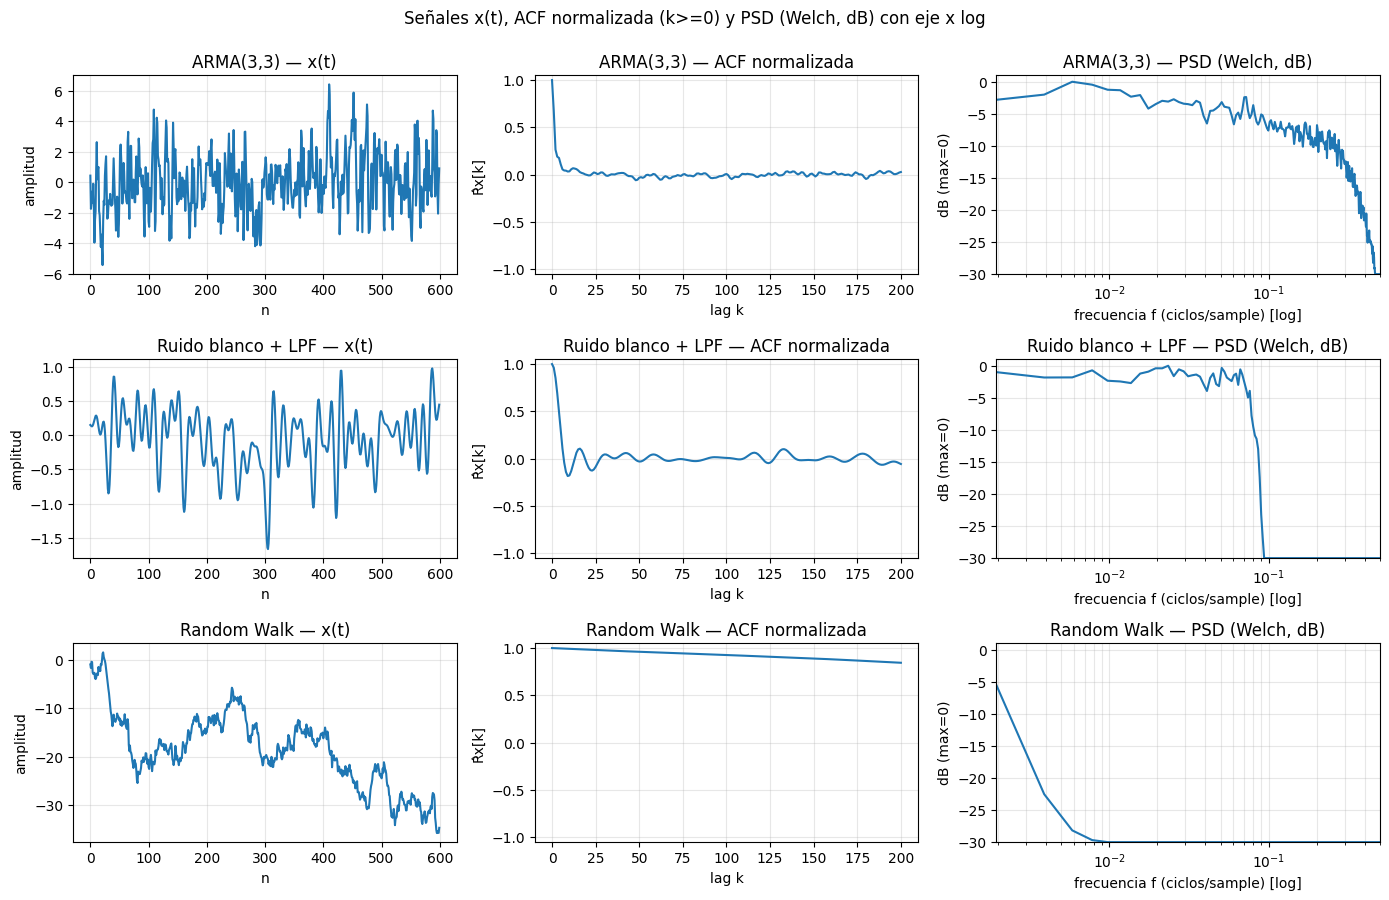

In [1]:
import torch
import matplotlib.pyplot as plt

# ---------------------------
# Configuración general
# ---------------------------
torch.manual_seed(0)
device = "cpu"
dtype = torch.float32

N = 4096          # longitud
Fs = 1.0          # frecuencia de muestreo (normalizada)
L = 200           # lags de la ACF (solo k>=0)
eps = 1e-12

# ---------------------------
# Utilidades
# ---------------------------
def next_pow2(n: int) -> int:
    p = 1
    while p < n:
        p *= 2
    return p

def generate_arma(phi, theta, N, burn_in=500, sigma=1.0):
    """
    x[n] = sum_{k=1..p} phi[k-1]*x[n-k] + e[n] + sum_{m=1..q} theta[m-1]*e[n-m]
    """
    phi = torch.tensor(phi, dtype=dtype, device=device)
    theta = torch.tensor(theta, dtype=dtype, device=device)
    p = phi.numel()
    q = theta.numel()

    total = N + burn_in
    e = sigma * torch.randn(total, dtype=dtype, device=device)
    x = torch.zeros(total, dtype=dtype, device=device)

    for n in range(total):
        ar_part = 0.0
        ma_part = 0.0

        # AR
        for k in range(1, p + 1):
            if n - k >= 0:
                ar_part = ar_part + phi[k - 1] * x[n - k]

        # MA
        for m in range(1, q + 1):
            if n - m >= 0:
                ma_part = ma_part + theta[m - 1] * e[n - m]

        x[n] = ar_part + e[n] + ma_part

    return x[burn_in:burn_in + N]

def fir_lowpass(cutoff, numtaps):
    """
    FIR LPF por sinc con ventana Hann.
    cutoff en ciclos/sample (0 < cutoff < 0.5).
    """
    M = numtaps - 1
    n = torch.arange(numtaps, dtype=dtype, device=device)
    h = 2 * cutoff * torch.sinc(2 * cutoff * (n - M / 2))
    w = torch.hann_window(numtaps, periodic=False, dtype=dtype, device=device)
    h = h * w
    h = h / (h.sum() + eps)  # ganancia DC = 1
    return h

def apply_fir(x, h):
    """
    Convolución 1D con padding para mantener longitud.
    """
    x_ = x.view(1, 1, -1)
    h_ = h.view(1, 1, -1)
    pad = (h.numel() - 1) // 2
    y = torch.nn.functional.conv1d(torch.nn.functional.pad(x_, (pad, pad)), h_)
    return y.view(-1)

def autocorr_semipositive_normalized(x, L):
    """
    ACF aperiódica vía FFT, devuelve lags k=0..L, normalizada por R[0].
    """
    x = x - x.mean()
    N = x.numel()
    nfft = next_pow2(2 * N)

    X = torch.fft.rfft(x, n=nfft)
    S = X * torch.conj(X)
    r = torch.fft.irfft(S, n=nfft)[:N]
    r0 = r[0].clamp_min(eps)
    r = r / r0
    return r[:L + 1]

def welch_psd_db(x, Fs=1.0, nperseg=512, noverlap=256):
    """
    PSD por Welch con ventana Hann.
    Devuelve (f, Pxx_db_clipped) con:
      - normalización para que max=0 dB
      - mínimo en -30 dB
    """
    x = x - x.mean()
    N = x.numel()
    hop = nperseg - noverlap
    if hop <= 0:
        raise ValueError("noverlap debe ser menor que nperseg.")

    window = torch.hann_window(nperseg, periodic=False, dtype=dtype, device=device)
    U = (window**2).sum().clamp_min(eps)

    starts = list(range(0, N - nperseg + 1, hop))
    if len(starts) == 0:
        raise ValueError("La señal es muy corta para nperseg.")

    Pxx_acc = None
    for s in starts:
        seg = x[s:s + nperseg] * window
        X = torch.fft.rfft(seg, n=nperseg)
        P = (X.real**2 + X.imag**2) / U
        Pxx_acc = P if Pxx_acc is None else (Pxx_acc + P)

    Pxx = Pxx_acc / len(starts)
    f = torch.fft.rfftfreq(nperseg, d=1.0 / Fs)

    Pxx_db = 10.0 * torch.log10(Pxx + eps)
    Pxx_db = Pxx_db - Pxx_db.max()
    Pxx_db = torch.clamp(Pxx_db, min=-30.0)
    return f, Pxx_db

# ---------------------------
# 1) Crear las 3 señales
# ARMA(3,3), Ruido blanco + LPF, Random Walk
# ---------------------------

# ARMA(3,3)
phi_arma33 = [0.75, -0.35, 0.20]
theta_arma33 = [0.65, -0.25, 0.10]
x_arma33 = generate_arma(phi_arma33, theta_arma33, N, burn_in=800, sigma=1.0)

# Ruido blanco -> LPF (RBG/RBO filtrado)
w = torch.randn(N, dtype=dtype, device=device)
h = fir_lowpass(cutoff=0.08, numtaps=101)
x_lpf = apply_fir(w, h)

# Random Walk
e = torch.randn(N, dtype=dtype, device=device)
x_rw = torch.cumsum(e, dim=0)

signals = [
    ("ARMA(3,3)", x_arma33),
    ("Ruido blanco + LPF", x_lpf),
    ("Random Walk", x_rw),
]

# ---------------------------
# 2) ACF y PSD para cada una
# ---------------------------
results = []
for name, x in signals:
    rx = autocorr_semipositive_normalized(x, L=L)
    f, Pdb = welch_psd_db(x, Fs=Fs, nperseg=512, noverlap=256)
    results.append((name, x, rx, f, Pdb))

# ---------------------------
# 3) Grilla 3x3: x(t), ACF, PSD (x en log)
# ---------------------------
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
fig.suptitle("Señales x(t), ACF normalizada (k>=0) y PSD (Welch, dB) con eje x log", y=0.995)

show_N = 600

for i, (name, x, rx, f, Pdb) in enumerate(results):
    # Col 1: x(t)
    ax = axes[i, 0]
    ax.plot(x[:show_N].cpu().numpy())
    ax.set_title(f"{name} — x(t)")
    ax.set_xlabel("n")
    ax.set_ylabel("amplitud")
    ax.grid(True, alpha=0.3)

    # Col 2: ACF
    ax = axes[i, 1]
    ax.plot(torch.arange(L+1).cpu().numpy(), rx.cpu().numpy())
    ax.set_title(f"{name} — ACF normalizada")
    ax.set_xlabel("lag k")
    ax.set_ylabel("R̂x[k]")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3)

    # Col 3: PSD con eje x en escala log (evitar f=0)
    ax = axes[i, 2]
    ax.semilogx(f[1:].cpu().numpy(), Pdb[1:].cpu().numpy())
    ax.set_title(f"{name} — PSD (Welch, dB)")
    ax.set_xlabel("frecuencia f (ciclos/sample) [log]")
    ax.set_ylabel("dB (max=0)")
    ax.set_ylim(-30, 1)
    ax.set_xlim(float(f[1]), float(f[-1]))
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Estimación de la PSD con el modelo: suma de gaussianas (pesos no negativos)

Queremos aproximar cada espectro de potencia (PSD) obtenido por Welch usando el modelo:

$$
\widehat{S}_{xx}(\lambda)=\sum_{k=1}^{K} w_k \exp\left(-\alpha_k \lambda^2\right),
\qquad w_k\ge 0,\ \alpha_k>0.
$$

- $\lambda$ representa la variable de frecuencia (normalizada), por ejemplo:
$$
\lambda = \frac{f}{f_{\max}}, \quad f\in[0,f_{\max}].
$$

Este modelo es **semipositivo** (no negativo) porque:
- $w_k\ge 0$
- $\exp(-\alpha_k\lambda^2)\ge 0$
- suma de términos no negativos $\Rightarrow \widehat{S}_{xx}(\lambda)\ge 0$.

---

## 1) Objetivo de optimización

Sea $S(\lambda)$ la PSD “original” calculada por Welch (trabajaremos en escala lineal, pero con un rango dinámico controlado usando el piso de $-30\,\text{dB}$):

1. Convertimos $S$ a dB y normalizamos para que el máximo sea $0$ dB:
$$
S_{dB}(\lambda) = 10\log_{10}(S(\lambda)+\varepsilon)-\max_{\lambda}\Big(10\log_{10}(S(\lambda)+\varepsilon)\Big)
$$

2. Se impone un piso (mínimo) de $-30$ dB:
$$
S_{dB}^{clip}(\lambda) = \max(S_{dB}(\lambda),-30)
$$

3. Volvemos a escala lineal para ajustar el modelo:
$$
S_{lin}^{clip}(\lambda)=10^{\frac{S_{dB}^{clip}(\lambda)}{10}}
\in [10^{-3}, 1].
$$

Ahora ajustamos $\widehat{S}_{xx}(\lambda)$ minimizando el **error cuadrático medio (ECM)**:
$$
\mathrm{ECM}=\frac{1}{M}\sum_{i=1}^{M}\left(\widehat{S}_{xx}(\lambda_i)-S_{lin}^{clip}(\lambda_i)\right)^2
$$

y además medimos la **norma 2 relativa**:
$$
\|\Delta\|_2=\frac{\left\|\widehat{S}_{xx}-S_{lin}^{clip}\right\|_2}{\left\|S_{lin}^{clip}\right\|_2}.
$$

---

## 2) Condición y búsqueda del \(K\) mínimo

Buscamos el **\(K\) más pequeño posible** tal que:

$$
\mathrm{ECM}<0.1
\quad\text{y}\quad
\|\Delta\|_2<0.1.
$$

Se prueba $K=1,2,3,\dots$ y se optimizan los parámetros $(w_k,\alpha_k)$ con descenso por gradiente (Adam).
Cuando se cumple el umbral, se detiene y se reporta el $K$ encontrado, junto con sus errores.

---

## 3) Visualización final

Para cada una de las 3 señales se grafica:
- PSD original (Welch) en dB (máx $0$ dB, piso $-30$ dB)
- PSD estimada $\widehat{S}_{xx}$ en dB (misma escala)

y se imprime:
- $K$ usado
- ECM
- norma 2 relativa

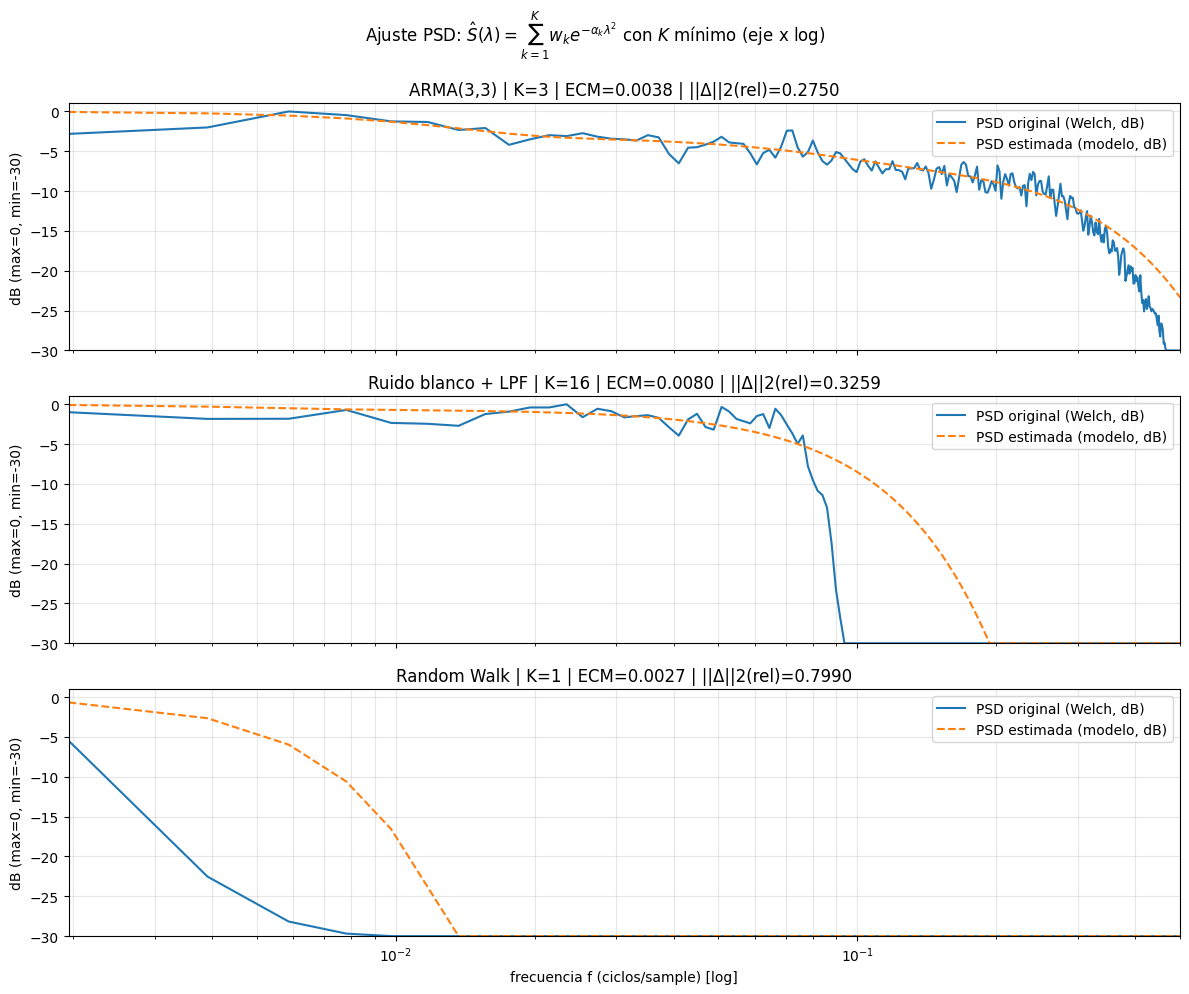


==== Resumen numérico ====
ARMA(3,3): K=3, ECM=0.003831, Norma2(rel)=0.274961
Ruido blanco + LPF: K=16, ECM=0.008041, Norma2(rel)=0.325914
Random Walk: K=1, ECM=0.002685, Norma2(rel)=0.798989


In [2]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cpu"
dtype = torch.float32
eps = 1e-12

# ---------------------------
# Config
# ---------------------------
N = 4096
Fs = 1.0

nperseg = 512
noverlap = 256

Kmax = 40
tol = 0.1
max_steps = 2500
lr = 5e-2
db_floor = -30.0

# ---------------------------
# Señales
# ---------------------------
def generate_arma(phi, theta, N, burn_in=800, sigma=1.0):
    phi = torch.tensor(phi, dtype=dtype, device=device)
    theta = torch.tensor(theta, dtype=dtype, device=device)
    p = phi.numel()
    q = theta.numel()
    total = N + burn_in
    e = sigma * torch.randn(total, dtype=dtype, device=device)
    x = torch.zeros(total, dtype=dtype, device=device)
    for n in range(total):
        ar_part = 0.0
        ma_part = 0.0
        for k in range(1, p + 1):
            if n - k >= 0:
                ar_part = ar_part + phi[k - 1] * x[n - k]
        for m in range(1, q + 1):
            if n - m >= 0:
                ma_part = ma_part + theta[m - 1] * e[n - m]
        x[n] = ar_part + e[n] + ma_part
    return x[burn_in:burn_in + N]

def fir_lowpass(cutoff, numtaps):
    M = numtaps - 1
    n = torch.arange(numtaps, dtype=dtype, device=device)
    h = 2 * cutoff * torch.sinc(2 * cutoff * (n - M / 2))
    w = torch.hann_window(numtaps, periodic=False, dtype=dtype, device=device)
    h = h * w
    h = h / (h.sum() + eps)
    return h

def apply_fir(x, h):
    x_ = x.view(1, 1, -1)
    h_ = h.view(1, 1, -1)
    pad = (h.numel() - 1) // 2
    y = torch.nn.functional.conv1d(torch.nn.functional.pad(x_, (pad, pad)), h_)
    return y.view(-1)

def welch_psd_linear(x, Fs=1.0, nperseg=512, noverlap=256):
    x = x - x.mean()
    N = x.numel()
    hop = nperseg - noverlap
    window = torch.hann_window(nperseg, periodic=False, dtype=dtype, device=device)
    U = (window**2).sum().clamp_min(eps)

    starts = list(range(0, N - nperseg + 1, hop))
    Pxx_acc = None
    for s in starts:
        seg = x[s:s + nperseg] * window
        X = torch.fft.rfft(seg, n=nperseg)
        P = (X.real**2 + X.imag**2) / U
        Pxx_acc = P if Pxx_acc is None else (Pxx_acc + P)

    Pxx = Pxx_acc / len(starts)
    f = torch.fft.rfftfreq(nperseg, d=1.0/Fs)
    return f, Pxx

def to_db_norm_clip(P, db_floor=-30.0):
    Pdb = 10.0 * torch.log10(P + eps)
    Pdb = Pdb - Pdb.max()
    return torch.clamp(Pdb, min=db_floor)

def db_to_linear(Pdb):
    return 10.0 ** (Pdb / 10.0)

# ---------------------------
# Ajuste estable: alpha = exp(log_alpha), w = softplus(raw_w)
# ---------------------------
def fit_psd_gaussian_sum(f, Pxx, K, max_steps=2000, lr=5e-2, tol=0.1, db_floor=-30.0):
    Pxx_db = to_db_norm_clip(Pxx, db_floor=db_floor)
    target = db_to_linear(Pxx_db)

    fmax = f.max().clamp_min(eps)
    lam = (f / fmax).detach()

    loga_init = torch.linspace(torch.log(torch.tensor(0.1)), torch.log(torch.tensor(100.0)), K).to(dtype).to(device)
    raw_w_init = torch.zeros(K, dtype=dtype, device=device)

    log_alpha = torch.nn.Parameter(loga_init.clone())
    raw_w = torch.nn.Parameter(raw_w_init.clone())

    opt = torch.optim.Adam([log_alpha, raw_w], lr=lr)

    def forward():
        alpha = torch.exp(log_alpha).clamp_max(1e4)
        w = torch.nn.functional.softplus(raw_w)

        Phi = torch.exp(-alpha.view(-1,1) * (lam.view(1,-1)**2))
        Shat = (w.view(-1,1) * Phi).sum(dim=0)

        Shat = Shat / (Shat.max().clamp_min(eps))
        return Shat, w, alpha

    Sh0, w0, a0 = forward()
    diff0 = Sh0 - target
    best_mse = (diff0**2).mean().item()
    best_rel = (torch.linalg.norm(diff0) / torch.linalg.norm(target)).item()
    best = Sh0.detach().clone()
    best_state = (w0.detach().clone(), a0.detach().clone())

    for _ in range(max_steps):
        Shat, w, alpha = forward()
        diff = Shat - target
        mse = (diff**2).mean()
        rel = torch.linalg.norm(diff) / torch.linalg.norm(target)

        if (not torch.isfinite(mse)) or (not torch.isfinite(rel)):
            break

        opt.zero_grad()
        mse.backward()
        opt.step()

        m = mse.item()
        r = rel.item()

        if m < best_mse:
            best_mse = m
            best_rel = r
            best = Shat.detach().clone()
            best_state = (w.detach().clone(), alpha.detach().clone())

        if best_mse < tol and best_rel < tol:
            break

    w_best, a_best = best_state
    return best, target, best_mse, best_rel, w_best, a_best, Pxx_db

def find_minK_for_psd(f, Pxx, Kmax=40, tol=0.1, **fit_kwargs):
    best_any = None
    for K in range(1, Kmax + 1):
        Shat, target, mse, rel, w, a, Pxx_db = fit_psd_gaussian_sum(f, Pxx, K, tol=tol, **fit_kwargs)
        if mse < tol and rel < tol:
            return K, Shat, target, mse, rel, w, a, Pxx_db
        if best_any is None or mse < best_any["mse"]:
            best_any = dict(K=K, Shat=Shat, target=target, mse=mse, rel=rel, w=w, a=a, Pxx_db=Pxx_db)
    return best_any["K"], best_any["Shat"], best_any["target"], best_any["mse"], best_any["rel"], best_any["w"], best_any["a"], best_any["Pxx_db"]

# ---------------------------
# Generar 3 señales (quitamos AR)
# ARMA(3,3), Ruido blanco + LPF, Random Walk
# ---------------------------

# ARMA(3,3)
phi_arma33 = [0.75, -0.35, 0.20]
theta_arma33 = [0.65, -0.25, 0.10]
x_arma = generate_arma(phi_arma33, theta_arma33, N)

# Ruido blanco + LPF
w_noise = torch.randn(N, dtype=dtype, device=device)
h = fir_lowpass(cutoff=0.08, numtaps=101)
x_lpf = apply_fir(w_noise, h)

# Random Walk
e = torch.randn(N, dtype=dtype, device=device)
x_rw = torch.cumsum(e, dim=0)

signals = [
    ("ARMA(3,3)", x_arma),
    ("Ruido blanco + LPF", x_lpf),
    ("Random Walk", x_rw),
]

# ---------------------------
# Ajustar y graficar (eje x log)
# ---------------------------
fits = []
for name, x in signals:
    f, Pxx = welch_psd_linear(x, Fs=Fs, nperseg=nperseg, noverlap=noverlap)
    K, Shat, target_lin, mse, rel, w_best, a_best, Pxx_db = find_minK_for_psd(
        f, Pxx,
        Kmax=Kmax,
        tol=tol,
        max_steps=max_steps,
        lr=lr,
        db_floor=db_floor
    )
    orig_db = Pxx_db
    hat_db = to_db_norm_clip(Shat, db_floor=db_floor)
    fits.append((name, f, orig_db, hat_db, K, mse, rel))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(r"Ajuste PSD: $\hat S(\lambda)=\sum_{k=1}^K w_k e^{-\alpha_k\lambda^2}$ con $K$ mínimo (eje x log)", y=0.99)

for i, (name, f, orig_db, hat_db, K, mse, rel) in enumerate(fits):
    ax = axes[i]
    ax.semilogx(f[1:].cpu().numpy(), orig_db[1:].cpu().numpy(), label="PSD original (Welch, dB)")
    ax.semilogx(f[1:].cpu().numpy(), hat_db[1:].cpu().numpy(), "--", label="PSD estimada (modelo, dB)")
    ax.set_title(f"{name} | K={K} | ECM={mse:.4f} | ||Δ||2(rel)={rel:.4f}")
    ax.set_ylabel("dB (max=0, min=-30)")
    ax.set_ylim(-30, 1)
    ax.set_xlim(float(f[1]), float(f[-1]))
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("frecuencia f (ciclos/sample) [log]")
plt.tight_layout()
plt.show()

print("\n==== Resumen numérico ====")
for (name, _, _, _, K, mse, rel) in fits:
    print(f"{name}: K={K}, ECM={mse:.6f}, Norma2(rel)={rel:.6f}")

# Reconstrucción del espectro de potencia usando producto interno (concordancia)

En esta sección se reconstruye el espectro de potencia (PSD) estimado por Welch a partir de un modelo paramétrico y se evalúa la calidad **no con $L_2$**, sino con una métrica basada en **producto interno** (concordancia).

---

## 1) PSD objetivo (Welch) y normalización

Para cada señal $x[n]$ se calcula la PSD con Welch, obteniendo $P_{xx}(f)$.  
Como el espectro puede tener un rango dinámico muy grande, se trabaja con una versión en dB normalizada y recortada:

1. Paso a dB:
$$
P_{dB}(f)=10\log_{10}(P_{xx}(f)+\varepsilon)
$$

2. Normalización para que el máximo sea $0$ dB:
$$
P_{dB}^{norm}(f)=P_{dB}(f)-\max_f P_{dB}(f)
$$

3. Piso a $-30$ dB:
$$
P_{dB}^{clip}(f)=\max\left(P_{dB}^{norm}(f),-30\right)
$$

4. Vuelta a escala lineal (para optimizar numéricamente):
$$
S(f)=10^{\frac{P_{dB}^{clip}(f)}{10}}
\quad\Rightarrow\quad
S(f)\in[10^{-3},1]
$$

Este $S(f)$ es el **espectro objetivo** que queremos aproximar.

---

## 2) Modelo de reconstrucción (base gaussiana)

Se aproxima el espectro con el modelo:

$$
\hat S(\lambda)=\sum_{k=1}^{K} w_k \exp(-\alpha_k\lambda^2),
\qquad w_k\ge 0,\ \alpha_k>0
$$

donde se usa frecuencia normalizada:

$$
\lambda=\frac{f}{f_{\max}}\in[0,1].
$$

El parámetro $K$ controla la complejidad:
- mayor $K$ $\Rightarrow$ más flexibilidad para reconstruir $S(f)$,
- pero también mayor número de parámetros ($w_k$ y $\alpha_k$).

---

## 3) Métrica basada en producto interno: concordancia

Para comparar el espectro objetivo $S$ y el reconstruido $\hat S$ se usa el **producto interno normalizado** (similitud coseno):

Sea el vector objetivo:
$$
\mathbf{s}=[S(f_1),\dots,S(f_M)]
$$

y el vector reconstruido:
$$
\hat{\mathbf{s}}=[\hat S(f_1),\dots,\hat S(f_M)].
$$

La concordancia es:

$$
\mathrm{conc}=
\frac{\langle \mathbf{s},\hat{\mathbf{s}}\rangle}
{\|\mathbf{s}\|_2\ \|\hat{\mathbf{s}}\|_2}
=
\frac{\sum_{i=1}^{M} s_i\hat s_i}
{\sqrt{\sum_{i=1}^{M}s_i^2}\ \sqrt{\sum_{i=1}^{M}\hat s_i^2}}
\in[0,1].
$$

En porcentaje:

$$
\%\mathrm{conc}=100\cdot \mathrm{conc}.
$$

**Interpretación:**
- $\mathrm{conc}=1$ significa que ambos espectros tienen **la misma forma global** (están alineados como vectores).
- valores cercanos a 0 indican espectros muy diferentes.

---

## 4) Objetivo del ajuste y selección de $K$

El entrenamiento busca **maximizar** la concordancia (equivalentemente minimizar $1-\mathrm{conc}$), y se selecciona el $K$ más pequeño que cumpla:

$$
\mathrm{conc}\ge 0.95
\quad\Longleftrightarrow\quad
\%\mathrm{conc}\ge 95\%.
$$

Esto garantiza:
- una reconstrucción suficientemente parecida al espectro original,
- con el **menor número de componentes** posible (modelo más simple).

---

## 5) Nota práctica: exclusión de $f=0$ en la comparación

Al graficar en escala logarítmica no se puede usar $f=0$, y además el punto DC puede dominar la similitud.  
Por eso la comparación y el ajuste se realizan sobre $f>0$ (es decir, usando $f[1:]$).

---

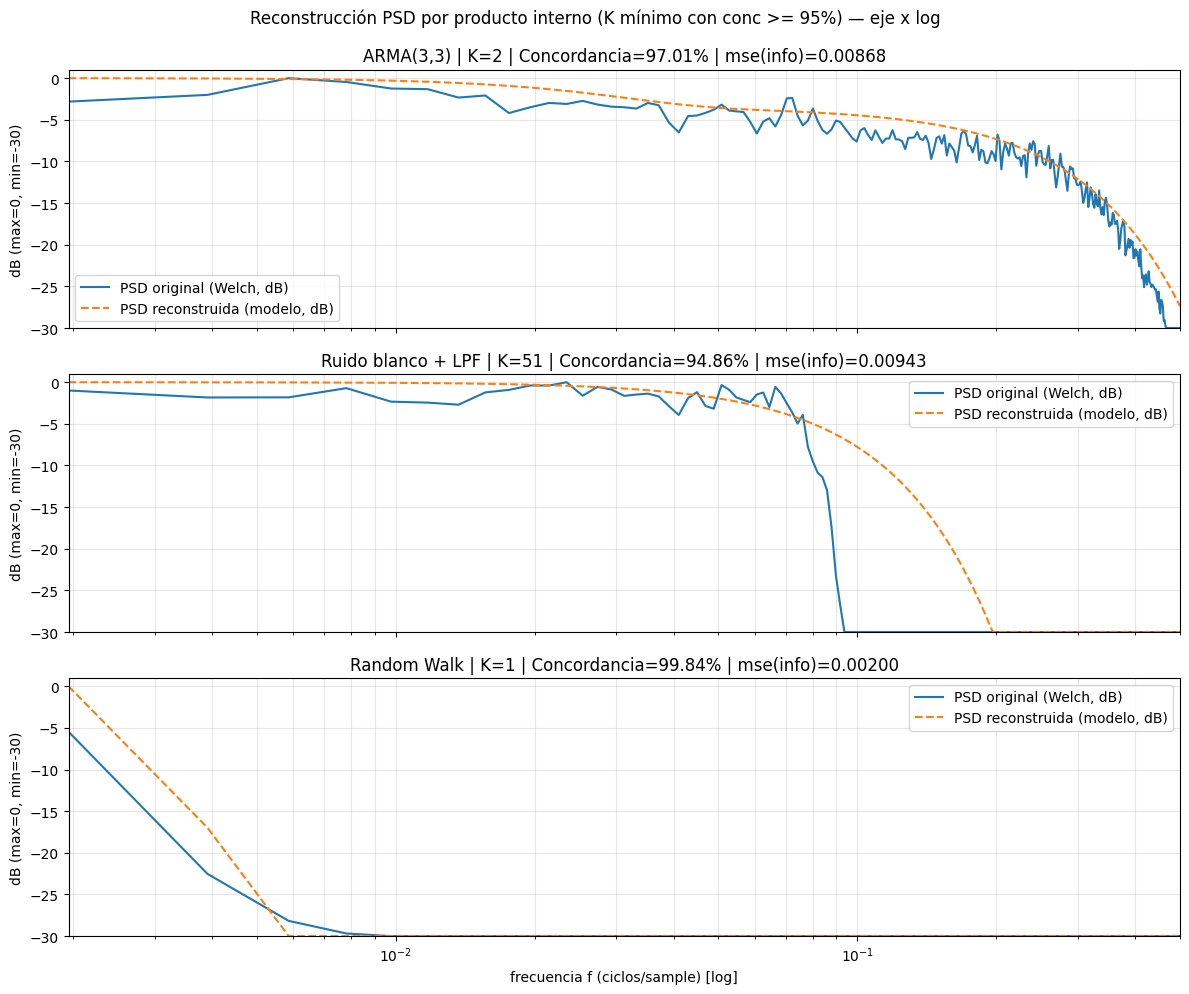

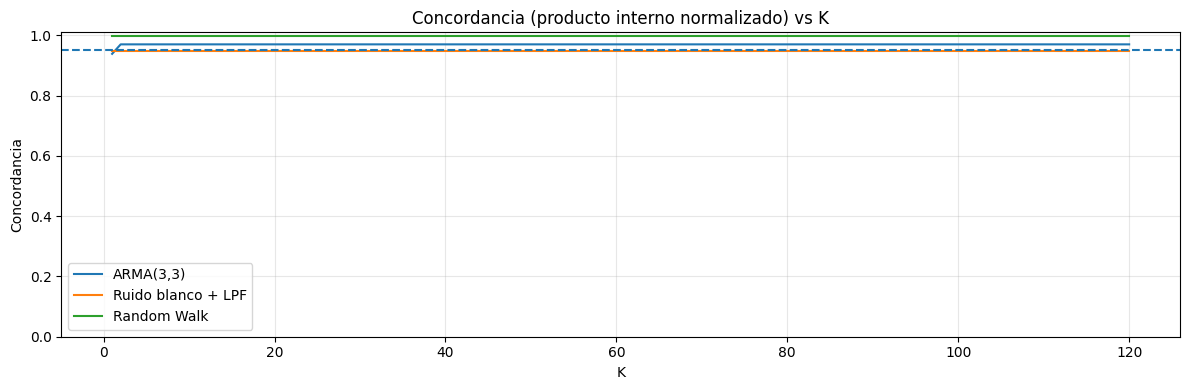


==== Resumen numérico (producto interno, K mínimo con conc >= 95%) ====

ARMA(3,3)
  K mínimo encontrado: 2
  Concordancia final: 97.0105%
  (mse informativo): 0.00868191
  alpha_k (len=2): [344.32703     5.4962087]
  w_k normalizados (len=2): [0.55474424 0.4452557 ]

Ruido blanco + LPF
  K mínimo encontrado: 51
  Concordancia final: 94.8606%
  (mse informativo): 0.00942787
  alpha_k (len=51): [44.801517 44.801563 44.801624 44.801464 44.801594 44.801617 44.801617
 44.801582 44.80153  44.80157  44.801647 44.801647 44.80154  44.801563
 44.801605 44.801647 44.80151  44.801445 44.801582 44.80153  44.801582
 44.80166  44.801464 44.801594 44.801517 44.80167  44.801582 44.80157
 44.80157  44.80153  44.80166  44.801594 44.801594 44.80153  44.80166
 44.80155  44.801517 44.801594 44.80153  44.80155  44.801594 44.801647
 44.80154  44.80155  44.80169  44.801563 44.80166  44.801624 44.801647
 44.801594 44.801594]
  w_k normalizados (len=51): [0.0199871  0.02050721 0.02091698 0.02188175 0.02203683 

In [4]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cpu"
dtype = torch.float32
eps = 1e-12

# ---------------------------
# Config
# ---------------------------
N = 4096
Fs = 1.0

nperseg = 512
noverlap = 256

Kmax = 120              # máximo K a probar
max_steps = 5000        # iteraciones de optimización (se ejecutan COMPLETAS por cada K)
lr = 3e-2               # learning rate
db_floor = -30.0

target_conc = 0.95      # requisito mínimo (>= 95%)

# Peso pequeño para estabilizar (NO es el criterio principal)
beta_mse = 0.05

# ---------------------------
# Señales
# ---------------------------
def generate_arma(phi, theta, N, burn_in=800, sigma=1.0):
    phi = torch.tensor(phi, dtype=dtype, device=device)
    theta = torch.tensor(theta, dtype=dtype, device=device)
    p = phi.numel()
    q = theta.numel()
    total = N + burn_in
    e = sigma * torch.randn(total, dtype=dtype, device=device)
    x = torch.zeros(total, dtype=dtype, device=device)
    for n in range(total):
        ar_part = 0.0
        ma_part = 0.0
        for k in range(1, p + 1):
            if n - k >= 0:
                ar_part = ar_part + phi[k - 1] * x[n - k]
        for m in range(1, q + 1):
            if n - m >= 0:
                ma_part = ma_part + theta[m - 1] * e[n - m]
        x[n] = ar_part + e[n] + ma_part
    return x[burn_in:burn_in + N]

def fir_lowpass(cutoff, numtaps):
    M = numtaps - 1
    n = torch.arange(numtaps, dtype=dtype, device=device)
    h = 2 * cutoff * torch.sinc(2 * cutoff * (n - M / 2))
    w = torch.hann_window(numtaps, periodic=False, dtype=dtype, device=device)
    h = h * w
    h = h / (h.sum() + eps)
    return h

def apply_fir(x, h):
    x_ = x.view(1, 1, -1)
    h_ = h.view(1, 1, -1)
    pad = (h.numel() - 1) // 2
    y = torch.nn.functional.conv1d(torch.nn.functional.pad(x_, (pad, pad)), h_)
    return y.view(-1)

# ---------------------------
# Welch PSD (lineal)
# ---------------------------
def welch_psd_linear(x, Fs=1.0, nperseg=512, noverlap=256):
    x = x - x.mean()
    N = x.numel()
    hop = nperseg - noverlap
    if hop <= 0:
        raise ValueError("noverlap debe ser menor que nperseg.")

    window = torch.hann_window(nperseg, periodic=False, dtype=dtype, device=device)
    U = (window**2).sum().clamp_min(eps)

    starts = list(range(0, N - nperseg + 1, hop))
    if len(starts) == 0:
        raise ValueError("La señal es muy corta para nperseg.")

    Pxx_acc = None
    for s in starts:
        seg = x[s:s + nperseg] * window
        X = torch.fft.rfft(seg, n=nperseg)
        P = (X.real**2 + X.imag**2) / U
        Pxx_acc = P if Pxx_acc is None else (Pxx_acc + P)

    Pxx = Pxx_acc / len(starts)
    f = torch.fft.rfftfreq(nperseg, d=1.0 / Fs)
    return f, Pxx

def to_db_norm_clip(P, db_floor=-30.0):
    Pdb = 10.0 * torch.log10(P + eps)
    Pdb = Pdb - Pdb.max()
    return torch.clamp(Pdb, min=db_floor)

def db_to_linear(Pdb):
    return 10.0 ** (Pdb / 10.0)

# ---------------------------
# Producto interno normalizado (similitud coseno)
# ---------------------------
def cosine_concordance(S, Shat):
    num = torch.dot(S, Shat)
    den = (torch.linalg.norm(S) * torch.linalg.norm(Shat)).clamp_min(eps)
    return (num / den).clamp(0.0, 1.0)

# ---------------------------
# Ajuste por producto interno
# IMPORTANTÍSIMO:
# - NO paramos al llegar al 95% dentro del entrenamiento.
# - Optimizamos max_steps COMPLETOS para cada K y guardamos el mejor resultado.
# ---------------------------
def fit_psd_by_inner_product_full(f, Pxx, K, max_steps=5000, lr=3e-2, db_floor=-30.0, beta_mse=0.05, warm=None):
    # Target: Welch -> dB norm+clip -> lineal en [1e-3,1]
    Pxx_db = to_db_norm_clip(Pxx, db_floor=db_floor)
    target = db_to_linear(Pxx_db).detach()

    # Quitamos DC (f=0) para log y para evitar dominancia del punto 0
    f1 = f[1:].detach()
    t1 = target[1:].detach()

    lam = (f1 / f1.max().clamp_min(eps)).detach()

    # Warm-start (solo acelera, no cambia el criterio)
    if warm is None:
        loga_init = torch.linspace(
            torch.log(torch.tensor(0.1, dtype=dtype, device=device)),
            torch.log(torch.tensor(100.0, dtype=dtype, device=device)),
            K
        )
        raw_w_init = torch.zeros(K, dtype=dtype, device=device)
    else:
        prev_log_alpha, prev_raw_w = warm
        # agregamos 1 componente nueva
        loga_init = torch.cat([prev_log_alpha, prev_log_alpha[-1:].clone()], dim=0)
        raw_w_init = torch.cat([prev_raw_w, torch.zeros(1, dtype=dtype, device=device)], dim=0)

    log_alpha = torch.nn.Parameter(loga_init.clone())
    raw_w = torch.nn.Parameter(raw_w_init.clone())
    opt = torch.optim.Adam([log_alpha, raw_w], lr=lr)

    best_conc = -1.0
    best_mse = float("inf")
    best_Shat = None
    best_state = None

    for _ in range(max_steps):
        alpha = torch.exp(log_alpha).clamp(1e-8, 1e8)
        w = torch.nn.functional.softplus(raw_w) + eps

        Phi = torch.exp(-alpha.view(-1, 1) * (lam.view(1, -1) ** 2))
        Shat = (w.view(-1, 1) * Phi).sum(dim=0)
        Shat = Shat / Shat.max().clamp_min(eps)

        conc = cosine_concordance(t1, Shat)
        mse = ((t1 - Shat) ** 2).mean()

        # objetivo principal: maximizar conc (minimizar 1-conc)
        # mse es solo estabilizador (peso pequeño)
        loss = (1.0 - conc) + beta_mse * mse

        if not torch.isfinite(loss):
            break

        opt.zero_grad()
        loss.backward()
        opt.step()

        c = conc.item()
        if c > best_conc:
            best_conc = c
            best_mse = mse.item()
            best_Shat = Shat.detach().clone()
            best_state = (log_alpha.detach().clone(), raw_w.detach().clone(), w.detach().clone(), alpha.detach().clone())

    best_log_alpha, best_raw_w, best_w, best_alpha = best_state
    warm_next = (best_log_alpha, best_raw_w)

    return best_Shat, target, best_conc, best_mse, best_w, best_alpha, Pxx_db, warm_next

# ---------------------------
# K mínimo que cumpla >=95%, pero con "mayor concordancia posible" por cada K:
# - Para cada K hacemos optimización completa (max_steps)
# - Calculamos la mejor concordancia alcanzada
# - Elegimos el PRIMER K que cumpla >=95%
# ---------------------------
def find_minK_minimal_that_reaches_threshold(f, Pxx, Kmax=120, target_conc=0.95, **fit_kwargs):
    warm = None
    conc_curve = []
    best_any = None

    for K in range(1, Kmax + 1):
        Shat, target, conc, mse, w, a, Pxx_db, warm = fit_psd_by_inner_product_full(
            f, Pxx, K, warm=warm, **fit_kwargs
        )

        conc_curve.append(conc)

        if best_any is None or conc > best_any["conc"]:
            best_any = dict(K=K, Shat=Shat, target=target, conc=conc, mse=mse, w=w, a=a, Pxx_db=Pxx_db)

        # criterio: al menos 95%
        if conc >= target_conc:
            return K, Shat, target, conc, mse, w, a, Pxx_db, conc_curve

    # si no llega, devolvemos el mejor
    return best_any["K"], best_any["Shat"], best_any["target"], best_any["conc"], best_any["mse"], best_any["w"], best_any["a"], best_any["Pxx_db"], conc_curve

# ---------------------------
# Generar 3 señales (ARMA(3,3), Ruido+LPF, Random Walk)
# ---------------------------
phi_arma33 = [0.75, -0.35, 0.20]
theta_arma33 = [0.65, -0.25, 0.10]
x_arma = generate_arma(phi_arma33, theta_arma33, N)

w_noise = torch.randn(N, dtype=dtype, device=device)
h = fir_lowpass(cutoff=0.08, numtaps=101)
x_lpf = apply_fir(w_noise, h)

e = torch.randn(N, dtype=dtype, device=device)
x_rw = torch.cumsum(e, dim=0)

signals = [
    ("ARMA(3,3)", x_arma),
    ("Ruido blanco + LPF", x_lpf),
    ("Random Walk", x_rw),
]

# ---------------------------
# Ajustar y graficar (eje x log) + curva conc vs K
# ---------------------------
fits = []
for name, x in signals:
    f, Pxx = welch_psd_linear(x, Fs=Fs, nperseg=nperseg, noverlap=noverlap)

    K, Shat_lin, target_lin, conc, mse, w_best, a_best, Pxx_db, conc_curve = find_minK_minimal_that_reaches_threshold(
        f, Pxx,
        Kmax=Kmax,
        target_conc=target_conc,
        max_steps=max_steps,
        lr=lr,
        db_floor=db_floor,
        beta_mse=beta_mse
    )

    # Shat_lin está definido sobre f[1:], así que el dB también (longitud 256)
    hat_db = to_db_norm_clip(Shat_lin, db_floor=db_floor)
    orig_db = Pxx_db

    w_norm = (w_best / w_best.sum().clamp_min(eps))

    fits.append((name, f, orig_db, hat_db, K, conc, mse, w_norm, a_best, conc_curve))

# ---- PSD plots
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("Reconstrucción PSD por producto interno (K mínimo con conc >= 95%) — eje x log", y=0.99)

for i, (name, f, orig_db, hat_db, K, conc, mse, w_norm, a_best, conc_curve) in enumerate(fits):
    ax = axes[i]
    f_plot = f[1:]
    ax.semilogx(f_plot.cpu().numpy(), orig_db[1:].cpu().numpy(), label="PSD original (Welch, dB)")
    ax.semilogx(f_plot.cpu().numpy(), hat_db.cpu().numpy(), "--", label="PSD reconstruida (modelo, dB)")
    ax.set_title(f"{name} | K={K} | Concordancia={100*conc:.2f}% | mse(info)={mse:.5f}")
    ax.set_ylabel("dB (max=0, min=-30)")
    ax.set_ylim(-30, 1)
    ax.set_xlim(float(f_plot[0]), float(f_plot[-1]))
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("frecuencia f (ciclos/sample) [log]")
plt.tight_layout()
plt.show()

# ---- Concordancia vs K (por señal)
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
Ks = torch.arange(1, Kmax + 1).cpu().numpy()

for (name, f, orig_db, hat_db, K, conc, mse, w_norm, a_best, conc_curve) in fits:
    y = conc_curve + [conc_curve[-1]] * (Kmax - len(conc_curve))  # relleno si terminó antes
    ax.plot(Ks, y, label=name)

ax.axhline(target_conc, linestyle="--")
ax.set_title("Concordancia (producto interno normalizado) vs K")
ax.set_xlabel("K")
ax.set_ylabel("Concordancia")
ax.set_ylim(0.0, 1.01)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ---- Reporte final
print("\n==== Resumen numérico (producto interno, K mínimo con conc >= 95%) ====")
for (name, _, _, _, K, conc, mse, w_norm, a_best, conc_curve) in fits:
    print(f"\n{name}")
    print(f"  K mínimo encontrado: {K}")
    print(f"  Concordancia final: {100*conc:.4f}%")
    print(f"  (mse informativo): {mse:.8f}")
    print(f"  alpha_k (len={K}): {a_best[:K].cpu().numpy()}")
    print(f"  w_k normalizados (len={K}): {w_norm[:K].cpu().numpy()}")

# Comparación de criterios de reconstrucción del espectro: norma $L_2$ vs producto interno

En la reconstrucción del espectro de potencia (PSD) queremos aproximar un espectro objetivo $S(f)$ (estimado con Welch) mediante un modelo $\hat S(f)$ (por ejemplo, suma de gaussianas).  
El punto clave es: **¿cómo definimos “qué tan buena” es la reconstrucción?**  
Dos criterios comunes son:

1. **Minimizar un error tipo norma $L_2$ (ECM / MSE)**.  
2. **Maximizar una similitud basada en producto interno (producto interno normalizado)**.

Ambos son válidos, pero optimizan cosas distintas y producen consecuencias diferentes.

---

## 1) Criterio basado en norma $L_2$ (ECM): cercanía punto a punto

### Definición
Sea el espectro muestreado en $M$ frecuencias:
$$
\mathbf{s} = [S(f_1), S(f_2), \dots, S(f_M)],\qquad
\hat{\mathbf{s}} = [\hat S(f_1), \hat S(f_2), \dots, \hat S(f_M)].
$$

La norma $L_2$ del error es:
$$
\|\hat{\mathbf{s}}-\mathbf{s}\|_2 = \sqrt{\sum_{i=1}^{M}(\hat s_i-s_i)^2}.
$$

En práctica se usa el **error cuadrático medio (ECM)**:
$$
\mathrm{ECM}=\frac{1}{M}\sum_{i=1}^{M}(\hat s_i-s_i)^2
= \frac{1}{M}\|\hat{\mathbf{s}}-\mathbf{s}\|_2^2.
$$

También se usa una medida **relativa**:
$$
\mathrm{err}_{rel}=\frac{\|\hat{\mathbf{s}}-\mathbf{s}\|_2}{\|\mathbf{s}\|_2}.
$$

### Interpretación (fenómeno)
Minimizar $L_2$ significa que el algoritmo intenta que la reconstrucción sea **cercana en cada punto** del espectro.  
En otras palabras: **castiga diferencias locales** (pico mal reconstruido, valle mal ubicado, etc.).

### Consecuencias prácticas
- **Ventaja:** si $\mathrm{ECM}$ es pequeño, la curva está cerca punto a punto en la mayoría de frecuencias.
- **Desventaja:** el $L_2$ puede estar dominado por regiones de gran energía.  
  Por ejemplo, si $S(f)$ tiene valores enormes en bajas frecuencias (caso típico del random walk), el error se concentra en esa zona y el ajuste puede priorizarla sobre el resto.
- **Sensibilidad al ruido de Welch:** fluctuaciones pequeñas punto a punto pueden aumentar el error, aun si visualmente el espectro se ve parecido.

---

## 2) Criterio basado en producto interno: similitud global (forma)

### Producto interno (no normalizado)
El producto interno entre dos espectros discretos es:
$$
\langle \mathbf{s}, \hat{\mathbf{s}}\rangle = \sum_{i=1}^{M} s_i \hat s_i.
$$

**Problema:** si $\hat{\mathbf{s}}$ se escala (por ejemplo $\hat{\mathbf{s}}\leftarrow c\hat{\mathbf{s}}$ con $c>1$), el producto interno aumenta aunque la forma no mejore.  
Por eso, para medir “parecido” se usa el **producto interno normalizado**.

### Producto interno normalizado (lo que realmente mide parecido)
La medida estándar es:
$$
\mathrm{sim}(\mathbf{s},\hat{\mathbf{s}})=
\frac{\langle \mathbf{s},\hat{\mathbf{s}}\rangle}{\|\mathbf{s}\|_2\,\|\hat{\mathbf{s}}\|_2},
\qquad 0\le \mathrm{sim}\le 1.
$$

En porcentaje:
$$
\%\mathrm{sim}=100\cdot \mathrm{sim}.
$$

### Interpretación geométrica
- $\mathbf{s}$ y $\hat{\mathbf{s}}$ son vectores en $\mathbb{R}^M$.
- La norma $L_2$ mide **distancia**.
- El producto interno normalizado mide el **ángulo** (alineación):
  - $\mathrm{sim}=1$ $\Rightarrow$ vectores alineados $\Rightarrow$ **misma forma global**.
  - $\mathrm{sim}$ grande $\Rightarrow$ espectros “se parecen” globalmente, aunque haya diferencias locales.

### Consecuencias prácticas
- **Ventaja:** tiende a producir reconstrucciones con forma global más parecida al espectro original (lo que a menudo coincide con “parecido visual”).
- **Ventaja:** es menos sensible a escalamiento global (por la normalización).
- **Desventaja:** puede dar una similitud alta aun si existen errores locales importantes en ciertas bandas, porque mide alineación global más que error punto a punto.

---

## 3) Diferencia conceptual central

- **$L_2$ (ECM) responde:**  
  “¿Qué tan cerca está $\hat S(f)$ de $S(f)$ en cada frecuencia?”

- **Producto interno normalizado responde:**  
  “¿Qué tan parecida es la forma global de $\hat S(f)$ respecto a $S(f)$?”

Esto explica por qué dos reconstrucciones pueden verse “parecidas” pero tener ECM diferente, o al revés.

---

## 4) Consecuencia importante en espectros con gran rango dinámico (ej. random walk)

En procesos como el random walk, el espectro suele estar muy concentrado en bajas frecuencias. Entonces:

- Con $L_2$, el ajuste puede quedar dominado por la región de mayor energía y penalizar fuerte errores allí.
- Con producto interno normalizado, si se logra alinear bien esa región dominante, la similitud global puede subir bastante, incluso si hay diferencias en frecuencias menos dominantes.

Por eso el criterio elegido cambia “qué considera importante” el algoritmo durante la reconstrucción.

---

## 5) Conclusión

- Minimizar $L_2$ (ECM) produce una reconstrucción **más estricta punto a punto**, pero puede ser sensible a regiones dominantes y a fluctuaciones del estimador.
- Maximizar el producto interno normalizado produce una reconstrucción que tiende a ser **más parecida en forma global**, útil cuando el objetivo es alta similitud con el espectro original.

En resumen:
$$
L_2 \Rightarrow \text{cercanía local (punto a punto)},\qquad
\text{producto interno normalizado} \Rightarrow \text{similitud global (forma)}.
$$

# Demostración teórica: validez de
$$
r_x(\lambda)=\sum_{k=1}^{K} w_k\,e^{-\alpha_k \lambda^2},\qquad w_k\ge 0,\ \alpha_k>0
$$
como función de autocorrelación (ACF)

El objetivo es demostrar que $r_x(\lambda)$ puede ser una **función de autocorrelación** de algún proceso aleatorio estacionario en sentido amplio (WSS).

---

## 1) Criterio de validez (Wiener–Khinchin / Bochner)

Una función $r_x(\lambda)$ es una ACF válida (de un proceso WSS) si y solo si su transformada de Fourier, que es la **densidad espectral de potencia (PSD)**, es **no negativa** para toda frecuencia:

$$
S_{xx}(\omega)=\mathcal{F}\{r_x(\lambda)\}=\int_{-\infty}^{\infty} r_x(\lambda)\,e^{-j\omega \lambda}\,d\lambda
$$

y debe cumplirse:

$$
S_{xx}(\omega)\ge 0\quad \forall\,\omega.
$$

Esto es exactamente la condición de **positividad semidefinida** (Bochner), y es la forma espectral del teorema de **Wiener–Khinchin**.

---

## 2) Transformada de Fourier de una gaussiana

Consideremos un término individual de la suma:

$$
r_k(\lambda)=e^{-\alpha_k \lambda^2},\qquad \alpha_k>0.
$$

Su transformada de Fourier es conocida (gaussiana se transforma en gaussiana). Con la convención:

$$
\mathcal{F}\{f(\lambda)\}(\omega)=\int_{-\infty}^{\infty} f(\lambda)\,e^{-j\omega\lambda}\,d\lambda,
$$

se cumple:

$$
\mathcal{F}\left\{e^{-\alpha_k \lambda^2}\right\}(\omega)=\sqrt{\frac{\pi}{\alpha_k}}\;e^{-\frac{\omega^2}{4\alpha_k}}.
$$

Observa que:

- $\sqrt{\frac{\pi}{\alpha_k}}>0$ porque $\alpha_k>0$,
- $e^{-\frac{\omega^2}{4\alpha_k}}>0$ para todo $\omega$,

por lo tanto:

$$
S_k(\omega)=\mathcal{F}\{r_k(\lambda)\}(\omega) > 0\quad \forall\,\omega.
$$

Es decir, **cada término genera una PSD estrictamente positiva**.

---

## 3) PSD del modelo completo (linealidad + pesos no negativos)

La autocorrelación propuesta es una suma ponderada:

$$
r_x(\lambda)=\sum_{k=1}^{K} w_k\,r_k(\lambda),
\qquad r_k(\lambda)=e^{-\alpha_k \lambda^2}.
$$

Usando la **linealidad** de la transformada de Fourier:

$$
S_{xx}(\omega)=\mathcal{F}\{r_x(\lambda)\}
= \sum_{k=1}^{K} w_k\,\mathcal{F}\{r_k(\lambda)\}.
$$

Sustituyendo el resultado del punto anterior:

$$
S_{xx}(\omega)=\sum_{k=1}^{K} w_k\sqrt{\frac{\pi}{\alpha_k}}\;e^{-\frac{\omega^2}{4\alpha_k}}.
$$

Ahora, como:

- $w_k\ge 0$,
- $\sqrt{\frac{\pi}{\alpha_k}}>0$,
- $e^{-\frac{\omega^2}{4\alpha_k}}>0$,

entonces cada sumando es **no negativo** y por lo tanto:

$$
S_{xx}(\omega)\ge 0\quad \forall\,\omega.
$$

---

## 4) Conclusión

Dado que la PSD asociada a $r_x(\lambda)$ es **no negativa para toda frecuencia**, por el teorema de **Wiener–Khinchin** (equivalentemente, por el criterio de **Bochner**), se concluye que:

$$
r_x(\lambda)=\sum_{k=1}^{K} w_k\,e^{-\alpha_k \lambda^2}
$$

es una **función de autocorrelación válida** para algún proceso aleatorio estacionario en sentido amplio, siempre que:

$$
w_k\ge 0,\qquad \alpha_k>0.
$$

---

# Prueba de estacionariedad (WSS) para 4 procesos

## 1) ¿Qué significa estacionariedad en sentido amplio (WSS)?
Un proceso $x[n]$ es **estacionario en sentido amplio** si cumple:

1. **Media constante**:
$$
\mu_x = \mathbb{E}\{x[n]\} \ \ \text{no depende de } n
$$

2. **Varianza constante**:
$$
\sigma_x^2 = \mathbb{E}\{(x[n]-\mu_x)^2\} \ \ \text{no depende de } n
$$

3. **Autocorrelación depende solo del retardo**:
$$
r_x[k] = \mathbb{E}\{x[n]\,x[n+k]\} \ \ \text{depende de } k,\ \text{no de } n
$$

---

## 2) ¿Cómo se prueba en la práctica (estimación empírica)?
Como no tenemos el proceso infinito sino una realización finita $x[n]$, hacemos una verificación empírica:

### (A) Media y varianza por ventanas
Dividimos la señal en $M$ segmentos (ventanas) de igual longitud.
Para cada ventana $m$ calculamos:

$$
\hat\mu_m = \frac{1}{N_w}\sum_{n\in \text{ventana }m} x[n]
$$

$$
\hat\sigma_m^2 = \frac{1}{N_w}\sum_{n\in \text{ventana }m} (x[n]-\hat\mu_m)^2
$$

**Interpretación:**
- Si $\hat\mu_m$ cambia mucho con $m$, la media no es constante → no WSS.
- Si $\hat\sigma_m^2$ cambia mucho con $m$, la varianza no es constante → no WSS.

---

### (B) ACF por ventanas (invarianza en el tiempo)
Se calcula la ACF normalizada global $\hat r[k]$ y también una ACF por cada ventana $\hat r_m[k]$.

**Interpretación:**
- Si las ACF de las ventanas son similares entre sí y a la global → consistente con WSS.
- Si cambian mucho entre ventanas → no WSS (o señal no suficientemente larga).

---

## 3) Resultados esperados (interpretación)
- **Ruido blanco + LPF:** WSS → media/varianza estables, ACF más ancha (por filtrado), PSD concentrada en bajas.
- **ARMA(3,3):** típicamente WSS si el AR es estable → media/varianza estables y ACF que decae.
- **Random walk:** NO es WSS → varianza crece con el tiempo y la señal deriva; por ventanas se observa cambio fuerte en estadísticas.

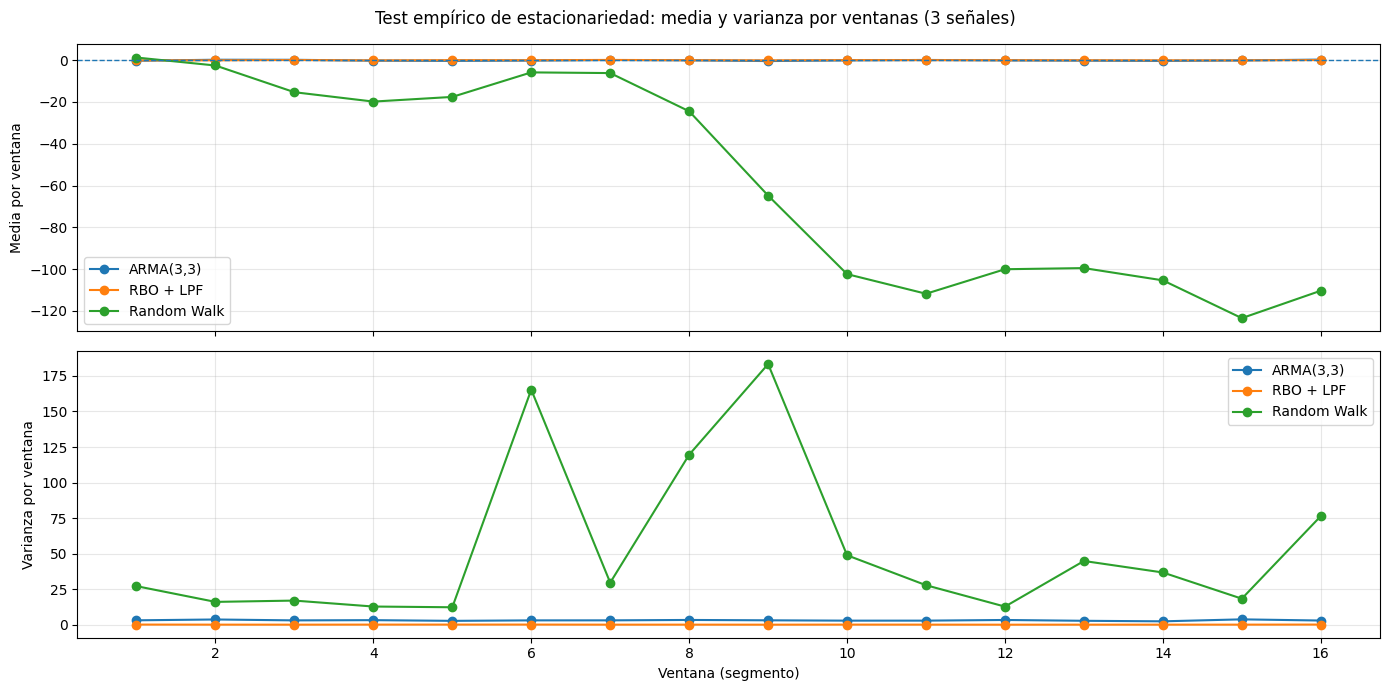

Ventanas: Mseg=16, seglen=256 muestras por ventana

ARMA(3,3)
  media global = -0.089760
  var global   = 3.227166
  rango medias = 0.708224
  ratio var    = 1.556128

RBO + LPF
  media global = -0.010709
  var global   = 0.169079
  rango medias = 0.231399
  ratio var    = 1.718180

Random Walk
  media global = -56.748505
  var global   = 2282.618408
  rango medias = 124.721672
  ratio var    = 14.814047


In [14]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cpu"
dtype = torch.float32
eps = 1e-12

# ---------------------------
# Parámetros
# ---------------------------
N = 4096
Mseg = 16                 # número de ventanas (más = más detalle, pero ventanas más cortas)
seglen = N // Mseg

# ---------------------------
# Generación de señales
# ---------------------------
def generate_arma(phi, theta, N, burn_in=800, sigma=1.0):
    phi = torch.tensor(phi, dtype=dtype, device=device)
    theta = torch.tensor(theta, dtype=dtype, device=device)
    p, q = phi.numel(), theta.numel()

    total = N + burn_in
    e = sigma * torch.randn(total, dtype=dtype, device=device)
    x = torch.zeros(total, dtype=dtype, device=device)

    for n in range(total):
        ar_part = 0.0
        ma_part = 0.0
        for k in range(1, p + 1):
            if n - k >= 0:
                ar_part += phi[k - 1] * x[n - k]
        for m in range(1, q + 1):
            if n - m >= 0:
                ma_part += theta[m - 1] * e[n - m]
        x[n] = ar_part + e[n] + ma_part

    return x[burn_in:burn_in + N]

def fir_lowpass(cutoff, numtaps):
    M = numtaps - 1
    n = torch.arange(numtaps, dtype=dtype, device=device)
    h = 2 * cutoff * torch.sinc(2 * cutoff * (n - M / 2))
    w = torch.hann_window(numtaps, periodic=False, dtype=dtype, device=device)
    h = h * w
    h = h / (h.sum() + eps)  # ganancia DC=1
    return h

def generate_white_lpf_stationary(N, cutoff=0.08, numtaps=101):
    """
    RBO + LPF en régimen: ruido más largo + conv 'valid' (sin padding)
    para evitar bordes que dañan el test.
    """
    h = fir_lowpass(cutoff, numtaps)
    w_long = torch.randn(N + numtaps - 1, dtype=dtype, device=device)
    y = torch.nn.functional.conv1d(
        w_long.view(1, 1, -1),
        h.view(1, 1, -1),
        padding=0
    ).view(-1)  # longitud N
    return y

# Señal 1: ARMA(3,3)
phi_arma33 = [0.75, -0.35, 0.20]
theta_arma33 = [0.65, -0.25, 0.10]
x_arma = generate_arma(phi_arma33, theta_arma33, N)

# Señal 2: RBO + LPF
x_lpf = generate_white_lpf_stationary(N, cutoff=0.08, numtaps=101)

# Señal 3: Random Walk
x_rw = torch.cumsum(torch.randn(N, dtype=dtype, device=device), dim=0)

signals = [
    ("ARMA(3,3)", x_arma),
    ("RBO + LPF", x_lpf),
    ("Random Walk", x_rw),
]

# ---------------------------
# Cálculo de media y varianza por ventanas
# ---------------------------
def window_stats(x, Mseg):
    Nn = x.numel()
    seglen = Nn // Mseg
    means = []
    vars_ = []
    for m in range(Mseg):
        seg = x[m*seglen:(m+1)*seglen]
        means.append(seg.mean())
        vars_.append(seg.var(unbiased=False))  # varianza poblacional
    return torch.stack(means), torch.stack(vars_), seglen

stats = []
for name, x in signals:
    means, vars_, seglen = window_stats(x, Mseg)
    stats.append((name, means, vars_, x.mean().item(), x.var(unbiased=False).item()))

# ---------------------------
# Plot único (una figura) con medias y varianzas
# ---------------------------
idx = torch.arange(1, Mseg + 1).cpu().numpy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Test empírico de estacionariedad: media y varianza por ventanas (3 señales)", y=0.98)

# Medias
for (name, means, vars_, mu_g, var_g) in stats:
    ax1.plot(idx, means.cpu().numpy(), marker="o", label=f"{name}")
ax1.axhline(0.0, linestyle="--", linewidth=1.0)
ax1.set_ylabel("Media por ventana")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Varianzas
for (name, means, vars_, mu_g, var_g) in stats:
    ax2.plot(idx, vars_.cpu().numpy(), marker="o", label=f"{name}")
ax2.set_ylabel("Varianza por ventana")
ax2.set_xlabel("Ventana (segmento)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Ventanas: Mseg={Mseg}, seglen={seglen} muestras por ventana")
for (name, means, vars_, mu_g, var_g) in stats:
    print(f"\n{name}")
    print(f"  media global = {mu_g:.6f}")
    print(f"  var global   = {var_g:.6f}")
    print(f"  rango medias = {(means.max()-means.min()).item():.6f}")
    print(f"  ratio var    = {(vars_.max()/vars_.min().clamp_min(eps)).item():.6f}")

# Conclusiones generales del cuaderno (Teoría de Señales)

## 1) Generación de señales y propósito del experimento
En el cuaderno se generaron tres procesos discretos representativos con comportamientos estadísticos distintos:

1. **ARMA(3,3)**: proceso estacionario (en sentido amplio) con memoria temporal controlada por términos autorregresivos (AR) y de media móvil (MA).  
2. **Ruido blanco filtrado por un pasa-bajos (RBO + LPF)**: proceso estacionario obtenido al aplicar un sistema LTI estable (FIR) a una entrada estacionaria, lo cual preserva la estacionariedad y redistribuye la potencia hacia bajas frecuencias.  
3. **Random Walk**: proceso no estacionario, construido como suma acumulada de ruido, con tendencia a presentar deriva y crecimiento temporal de la varianza.

La selección de estos procesos permitió contrastar, de manera clara, el efecto de **memoria**, **filtrado espectral** y **no estacionariedad** sobre la **función de autocorrelación** y sobre la **densidad espectral de potencia (PSD)**.

---

## 2) Función de autocorrelación (ACF): interpretación de memoria y dependencia temporal
Para cada señal se estimó la autocorrelación normalizada (semi-positiva y para retardos $k\ge 0$), usando un enfoque basado en FFT. Esta ACF normalizada cumple:
$$
\hat r_x[0]=1,\qquad \hat r_x[k]=\frac{r_x[k]}{r_x[0]}.
$$

En términos interpretativos:
- En **ARMA(3,3)** la ACF decae gradualmente, lo cual evidencia **dependencia temporal** y **memoria** del proceso.
- En **RBO + LPF** la ACF resulta **más ancha** que la del ruido blanco, porque el filtrado pasa-bajos introduce correlación entre muestras cercanas.
- En **Random Walk** la dependencia temporal es muy fuerte; sin embargo, al no ser un proceso WSS, las propiedades teóricas clásicas de ACF estacionaria no aplican estrictamente, y la ACF estimada se interpreta como una caracterización empírica de la realización.

---

## 3) Espectro de potencia (PSD) por Welch: contenido frecuencial y semipositividad
La PSD se estimó mediante el método de **Welch**, empleando segmentación, ventana Hann y promediado, con presentación en dB y un piso de $-30$ dB para facilitar la visualización:

- La PSD es semipositiva por construcción:
$$
\hat S_{xx}(f)\ge 0,
$$
y su interpretación describe cómo se distribuye la potencia de la señal en el dominio de frecuencia.

Resultados esperados y observados:
- **ARMA(3,3)**: espectro moldeado por la dinámica del sistema ARMA; no es plano como el ruido blanco.
- **RBO + LPF**: concentración evidente de potencia en bajas frecuencias, consistente con la acción del filtro pasa-bajos:
$$
S_{yy}(f)=|H(f)|^2 S_{xx}(f).
$$
- **Random Walk**: fuerte dominancia de bajas frecuencias (componente tipo “muy baja frecuencia”), coherente con el carácter acumulativo del proceso.

---

## 4) Reconstrucción del espectro: dos criterios de optimización (dos enfoques)
Se propuso un modelo paramétrico para aproximar el espectro de potencia a partir de una suma de gaussianas en una variable normalizada $\lambda\in[0,1]$:

$$
\hat S(\lambda)=\sum_{k=1}^{K} w_k e^{-\alpha_k \lambda^2},
\qquad w_k\ge 0,\ \alpha_k>0.
$$

El objetivo fue reconstruir el espectro con un **$K$ tan pequeño como sea posible**, bajo un criterio de error o similitud. Para ello se evaluaron dos enfoques:

### (A) Reconstrucción por norma $L_2$ (ECM / error cuadrático medio)
En este caso se minimiza la diferencia punto a punto entre el espectro objetivo y el espectro reconstruido, típicamente mediante:

$$
\mathrm{ECM}=\frac{1}{M}\sum_{i=1}^{M}\left(\hat S_i - S_i\right)^2.
$$

**Consecuencia principal:** este criterio fuerza al algoritmo a reducir el error local (frecuencia a frecuencia), lo cual suele producir reconstrucciones visualmente “pegadas” en regiones específicas, pero puede ser sensible a regiones dominantes del espectro y a fluctuaciones del estimador.

### (B) Reconstrucción por producto interno (producto punto) con normalización
En este enfoque se compara el espectro reconstruido con el espectro original mediante el **producto interno normalizado**, que mide similitud global:

$$
\mathrm{sim}=\frac{\langle S,\hat S\rangle}{\|S\|_2\ \|\hat S\|_2}\in[0,1],
\qquad \%\mathrm{sim}=100\cdot\mathrm{sim}.
$$

Se buscó el **$K$ mínimo** tal que:
$$
\mathrm{sim}\ge 0.95,
$$
es decir, una similitud de al menos $95\%$.

**Consecuencia principal:** el producto interno normalizado prioriza la **alineación global** entre espectros (forma general), lo cual es coherente con una métrica de “parecido” entre vectores espectrales. En general, puede requerir un $K$ menor para alcanzar el umbral de similitud, puesto que no penaliza del mismo modo errores locales pequeños, sino la discrepancia global del patrón.

En resumen, ambos enfoques son consistentes, pero optimizan objetivos distintos:
$$
L_2 \Rightarrow \text{cercanía local punto a punto},\qquad
\text{producto interno normalizado} \Rightarrow \text{similitud global de forma}.
$$

---

## 5) Pruebas empíricas de estacionariedad: medias y varianzas por ventanas
Finalmente se implementó un test empírico de estacionariedad (WSS) basado en comparar, por ventanas, las estimaciones de:

- media por segmento $\hat\mu_m$,
- varianza por segmento $\hat\sigma_m^2$,

contra los valores globales.

Para un proceso WSS se espera:
$$
\mu_x=\mathbb{E}\{x[n]\}\ \text{constante},\qquad
\sigma_x^2=\mathbb{E}\{(x[n]-\mu_x)^2\}\ \text{constante}.
$$

El análisis por ventanas permitió observar:

- **ARMA(3,3)**: medias y varianzas relativamente estables entre ventanas, coherente con un proceso WSS (bajo parámetros estables).
- **RBO + LPF**: también presenta estabilidad de media/varianza por ventanas; además, se resaltó la importancia de evitar efectos de borde del filtrado (condiciones iniciales) para que la estacionariedad empírica se aprecie correctamente.
- **Random Walk**: varianza no constante y cambios notables entre ventanas, lo cual confirma su **no estacionariedad**.

---

## 6) Cierre conceptual
El cuaderno integró coherentemente cuatro ideas centrales del análisis de procesos aleatorios:

1. **La ACF** caracteriza la memoria temporal y la dependencia entre muestras.  
2. **La PSD** describe la distribución de potencia en frecuencia, y es semipositiva.  
3. **La reconstrucción paramétrica** del espectro depende críticamente del criterio de ajuste:  
   - $L_2$ enfatiza precisión local,  
   - producto interno normalizado enfatiza similitud global.  
4. **La estacionariedad** puede verificarse empíricamente mediante estabilidad de media y varianza por ventanas, distinguiendo claramente procesos WSS (ARMA y RBO+LPF) de procesos no WSS (Random Walk).

En conclusión, los resultados obtenidos son consistentes con la teoría: el filtrado pasa-bajos modifica el contenido espectral y ensancha la correlación, los modelos ARMA exhiben dependencia temporal estacionaria, y el random walk se identifica como no estacionario por su comportamiento acumulativo y varianza creciente en el tiempo.